In [1]:
import h5py

path = "msd_summary_file.h5"   # <-- adjust path if needed

with h5py.File(path, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print()

    def walk(name, obj):
        if isinstance(obj, h5py.Group):
            print(f"[Group ] {name}")
            for k in obj.keys():
                walk(f"{name}/{k}", obj[k])
        else:
            print(f"[Dataset] {name}  shape={obj.shape}  dtype={obj.dtype}")

    walk("/", f)

OSError: Unable to synchronously open file (file signature not found)

In [ ]:
# -----------------------------
# CONFIG: choose dataset version
# -----------------------------

VERSION = "1000"    # or "50000"

DATA_DIR = f"./out_{VERSION}"

ACOUSTIC_FILE = f"{DATA_DIR}/acoustic_{VERSION}.parquet"
UMAP_FILE     = f"{DATA_DIR}/acoustic_umap_{VERSION}.parquet"
BEHAV_FILE    = f"{DATA_DIR}/behavior_edges_{VERSION}.parquet"
TDA_FILE      = f"{DATA_DIR}/tda_summary_{VERSION}.json"

# ACOUSTIC_FILE = f"out/acoustic.parquet"
# UMAP_FILE     = f"out/acoustic_umap.parquet"
# BEHAV_FILE    = f"out/behavior_edges.parquet"
# TDA_FILE      = f"out/tda_summary.json"

print("Using dataset version:", VERSION)
print("Acoustic:", ACOUSTIC_FILE)
print("UMAP:", UMAP_FILE)
print("Behavior:", BEHAV_FILE)
print("TDA summary:", TDA_FILE)

In [ ]:


# AC0 - Acoustic persistence diagram

import pandas as pd
import numpy as np
import os
from ripser import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt

# Load acoustic features
df = pd.read_parquet(ACOUSTIC_FILE)

NUMERIC_COLS = ['tempo','loudness','time_sig','key','mode','duration','danceability','energy']

# Use SAME subsample as the pipeline (random_state=42 is essential)
TDA_SUBSAMPLE = 1200
df_tda = df.sample(n=min(TDA_SUBSAMPLE, len(df)), random_state=42).reset_index(drop=True)

# Acoustic feature matrix
X = df_tda[NUMERIC_COLS].to_numpy(dtype=np.float32)

def pairwise_dist(X):
    G = X @ X.T
    diag = np.sum(X*X, axis=1)
    D2 = diag[:,None] + diag[None,:] - 2.0*G
    D2[D2 < 0] = 0.0
    return np.sqrt(D2, dtype=np.float32)

# Acoustic distance matrix
D_ac = pairwise_dist(X)

# Persistence computation
dgms_ac = ripser(D_ac, distance_matrix=True, maxdim=1)['dgms']

# Plot
plt.figure(figsize=(6,5))
plot_diagrams(dgms_ac, title="Acoustic Persistence Diagram")
plt.show()


In [ ]:
# AC1 - Behavioral persistence diagram

import pandas as pd
import numpy as np
from ripser import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt

edges = pd.read_parquet(BEHAV_FILE)

# map back to acoustic sample indices
song_to_idx = {s:i for i,s in enumerate(df['song_id'])}
keep_idx = np.array([song_to_idx[s] for s in df_tda['song_id']], dtype=int)
keep_set = set(keep_idx)

sub_edges = []
for a,b,w in edges[['a','b','w']].to_numpy():
    if a in keep_set and b in keep_set:
        sub_edges.append((list(keep_set).index(a), list(keep_set).index(b), w))

def shortest_path_dist(n, edges):
    import heapq
    INF = 1e12
    if not edges:
        D = np.ones((n,n), dtype=np.float32)
        np.fill_diagonal(D,0.0)
        return D
    adj = [[] for _ in range(n)]
    for a,b,w in edges:
        d = 1.0 / max(1.0, float(w))
        adj[a].append((b,d)); adj[b].append((a,d))
    D = np.full((n,n), INF, dtype=np.float32)
    for s in range(n):
        D[s,s] = 0.0
        pq = [(0.0,s)]
        while pq:
            d,u = heapq.heappop(pq)
            if d > D[s,u]: continue
            for v,w in adj[u]:
                nd = d+w
                if nd < D[s,v]:
                    D[s,v] = nd
                    heapq.heappush(pq,(nd,v))
    finite = np.isfinite(D)
    off = D[finite & ~np.eye(n,dtype=bool)]
    cap = float(np.max(off)) if off.size>0 else 1.0
    D[~finite] = cap
    return D

D_be = shortest_path_dist(len(df_tda), sub_edges)

dgms_be = ripser(D_be, distance_matrix=True, maxdim=1)['dgms']

plt.figure(figsize=(6,5))
plot_diagrams(dgms_be, title="Behavioral Persistence Diagram")
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load UMAP
umap_df = pd.read_parquet(UMAP_FILE)

# Fit KMeans to reveal cluster structure (choose k ~ 8, tweak later)
kmeans = KMeans(n_clusters=8, random_state=42).fit(umap_df[['x', 'y']])
umap_df['cluster'] = kmeans.labels_

# Plot
plt.figure(figsize=(9,7))
for c in sorted(umap_df['cluster'].unique()):
    subset = umap_df[umap_df['cluster'] == c]
    plt.scatter(subset['x'], subset['y'], s=5, alpha=0.7, label=f"Cluster {c}")

plt.title("Acoustic Song Embedding (UMAP) with Clusters")
plt.xlabel("UMAP-X")
plt.ylabel("UMAP-Y")
plt.legend(markerscale=4, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [ ]:
# UMAP clusters (uses existing labels in the file)
import pandas as pd
import matplotlib.pyplot as plt

umap_df = pd.read_parquet(UMAP_FILE)  # has x, y, cluster, song_id

plt.figure(figsize=(9,7))
for c in sorted(umap_df['cluster'].unique()):
    pts = umap_df[umap_df['cluster'] == c]
    plt.scatter(pts['x'], pts['y'], s=5, alpha=0.7, label=f"Cluster {c}")


plt.title("Acoustic UMAP with Clusters (HDBSCAN from pipeline)")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(markerscale=4, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.show()


In [ ]:
!pip install networkx


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Load data
edges = pd.read_parquet(BEHAV_FILE)
umap_df = pd.read_parquet(UMAP_FILE)

# Debug print
print("Edge columns:", edges.columns.tolist())

# Handle weight or no-weight edges
if "weight" in edges.columns:
    edges_strong = edges[edges["weight"] >= 5]
else:
    print("No 'weight' column found — treating edges as unweighted.")
    edges_strong = edges.copy()

# Build graph
G = nx.from_pandas_edgelist(edges_strong, source="a", target="b")

# UMAP-based node positions
pos = {row.song_id: (row.x, row.y) for _, row in umap_df.iterrows()}

# Node colors
node_colors = umap_df.set_index("song_id")["cluster"].to_dict()
color_list = [node_colors.get(n, -1) for n in G.nodes()]

# Draw with thicker edges + nodes
plt.figure(figsize=(12, 12))
nx.draw(
    G,
    pos=pos,
    node_size=8,         # THICKER NODES (default was 2)
    linewidths=0,
    alpha=0.7,           # slightly stronger opacity
    cmap="tab10",
    node_color=color_list,
    edge_color="black",  # darker edges
    width=0.3            # THICKER EDGES (default was 0.05)
)

plt.title("Behavioral Co-Listening Connectivity Overlaid on Acoustic Space", fontsize=14)
plt.show()

: 

In [9]:
!pip install networkx


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


Nodes: 1000 | Edges (drawn): 4519 | Components: 1 | Largest: 1000


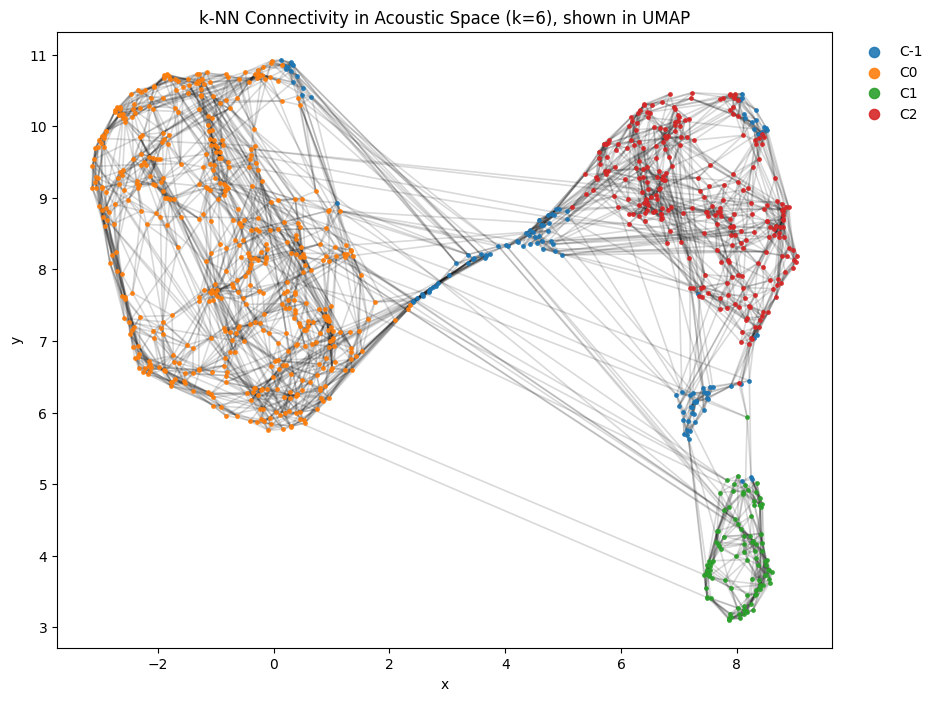

In [10]:
# Connectivity graph overlay (k-NN in acoustic feature space, drawn in UMAP)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import networkx as nxaa
import random

# load UMAP positions + acoustic features and align by song_id
umap_df = pd.read_parquet(UMAP_FILE)[['song_id','x','y','cluster']]
ac = pd.read_parquet(ACOUSTIC_FILE)
NUMERIC_COLS = ['tempo','loudness','time_sig','key','mode','duration','danceability','energy']

dfm = umap_df.merge(ac[['song_id'] + NUMERIC_COLS], on='song_id', how='inner').reset_index(drop=True)
X = dfm[NUMERIC_COLS].to_numpy(dtype=np.float32)
coords = dfm[['x','y']].to_numpy()

# build kNN graph in acoustic space
k = 6  # tweak: 4–12 gives nice structure
nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X)
knn_idx = nbrs.kneighbors(return_distance=False)

edges = []
for i, row in enumerate(knn_idx):
    for j in row[1:]:   # skip self
        a, b = (i, j) if i < j else (j, i)
        edges.append((a, b))
edges = list(set(edges))  # dedupe

# optional: subsample edges for speed/clarity
MAX_EDGES = 30_000
if len(edges) > MAX_EDGES:
    random.seed(42)
    edges = random.sample(edges, MAX_EDGES)

# simple connectivity stats
G = nx.Graph()
G.add_nodes_from(range(len(dfm)))
G.add_edges_from(edges)
cc_sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
print(f"Nodes: {len(dfm)} | Edges (drawn): {len(edges)} | Components: {len(cc_sizes)} | Largest: {cc_sizes[0]}")

# draw
plt.figure(figsize=(10,8))
# edges (light)
for a, b in edges:
    xa, ya = coords[a]
    xb, yb = coords[b]
    plt.plot([xa, xb], [ya, yb], lw=1.2, alpha=0.15, color="black", zorder=1)

# nodes (colored by existing cluster)
for c in sorted(dfm['cluster'].unique()):
    pts = dfm[dfm['cluster'] == c]
    plt.scatter(pts['x'], pts['y'], s=6, alpha=0.9, zorder=2, label=f"C{c}")

plt.title(f"k-NN Connectivity in Acoustic Space (k={k}), shown in UMAP")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(markerscale=3, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.show()


In [12]:
import pandas as pd

umap = pd.read_parquet(UMAP_FILE)
meta = pd.read_parquet("./out/artist_terms.parquet")

# ✅ convert all song_id to str (remove b'...' encoding differences)
umap["song_id"] = umap["song_id"].astype(str)
meta["song_id"] = meta["song_id"].astype(str)

merged = umap.merge(meta, on="song_id", how="inner")
print(len(merged), "songs merged")
merged.head()


10 songs merged


,x,y,cluster,song_id,artist_name,artist_terms
0,-1.482976,10.652863,0,SOJRNQF12A8C134D57,Beenie Man Featuring Wyclef And Redman,"[dancehall, reggae, raga, hardcore, jamaica, j..."
1,6.724794,9.784421,2,SODKOLK12A6D4FB6B1,Tommy James And The Shondells,"[brill building pop, pop rock, psychedelic roc..."
2,-0.823931,10.727720,0,SOASNQV12A8AE48819,The Prodigy,"[hardcore techno, rave, hip hop, techno, rap, ..."
3,-1.104041,9.470828,0,SOAGASM12A8C13DEBF,Sophie Tucker,"[vaudeville, easy listening, cabaret, country ..."
4,-0.383738,8.544091,0,SOEJGDS12A8C13875E,The Sun Harbor's Chorus-Documentary Recordings,"[patriotic, up beat, classic, beautiful, unite..."


In [13]:
from collections import Counter

cluster_genres = {}

for c, group in merged.groupby("cluster"):
    terms = [t for terms_list in group["artist_terms"] for t in terms_list]
    counter = Counter(terms)
    cluster_genres[c] = counter.most_common(25)  # look at top 25 to interpret patterns

for c in sorted(cluster_genres.keys()):
    print(f"\n=== Cluster {c} ===")
    for term, count in cluster_genres[c][:12]:
        print(f"{term:<25} {count}")



=== Cluster 0 ===
pop                       6
rock                      5
hardcore                  4
classic                   4
hip hop                   3
rap                       3
vocal                     3
alternative rock          3
punk                      3
alternative               3
united states             3
industrial                3

=== Cluster 2 ===
soul                      2
american                  2
brill building pop        1
pop rock                  1
psychedelic rock          1
classic rock              1
soft rock                 1
blues-rock                1
ballad                    1
rock                      1
disco                     1
garage rock               1


In [14]:
from collections import Counter, defaultdict
import math

# cluster -> Counter(tag)
cluster_counts = {}
for c, group in merged.groupby("cluster"):
    tags = [t for ts in group.artist_terms for t in ts]
    cluster_counts[c] = Counter(tags)

# tag -> number of clusters it appears in
tag_cluster_presence = defaultdict(int)
for tag in set(t for tags in cluster_counts.values() for t in tags):
    for c in cluster_counts:
        if tag in cluster_counts[c]:
            tag_cluster_presence[tag] += 1

num_clusters = len(cluster_counts)

# compute tf-idf style weights
cluster_weights = {}
for c, counter in cluster_counts.items():
    weighted = []
    for tag, freq in counter.items():
        idf = math.log(num_clusters / tag_cluster_presence[tag])
        weighted.append((tag, freq * idf))
    weighted.sort(key=lambda x: x[1], reverse=True)
    cluster_weights[c] = weighted[:15]

# Display results
for c in sorted(cluster_weights):
    print(f"\n=== DISTINCTIVE GENRES FOR CLUSTER {c} ===")
    for tag, w in cluster_weights[c]:
        print(f"{tag:<25} {w:.3f}")



=== DISTINCTIVE GENRES FOR CLUSTER 0 ===
hardcore                  2.773
classic                   2.773
rap                       2.079
alternative rock          2.079
punk                      2.079
alternative               2.079
industrial                2.079
metal                     2.079
remix                     1.386
90s                       1.386
techno                    1.386
electronica               1.386
female                    1.386
indie                     1.386
southern rock             1.386

=== DISTINCTIVE GENRES FOR CLUSTER 2 ===
brill building pop        0.693
psychedelic rock          0.693
soft rock                 0.693
blues-rock                0.693
garage rock               0.693
german pop                0.693
country rock              0.693
europop                   0.693
folk rock                 0.693
british invasion          0.693
pop rap                   0.693
piano blues               0.693
close harmony             0.693
rockabilly          

In [17]:
from collections import Counter, defaultdict
import math
import pandas as pd

# merged contains: song_id, x, y, cluster, artist_name, artist_terms

# Count artists within each cluster
cluster_artist_counts = {}
for c, group in merged.groupby("cluster"):
    artists = group["artist_name"].astype(str).tolist()
    cluster_artist_counts[c] = Counter(artists)

# Count how many clusters each artist appears in
artist_cluster_presence = defaultdict(int)
for artist in set(a for counts in cluster_artist_counts.values() for a in counts):
    for c in cluster_artist_counts:
        if artist in cluster_artist_counts[c]:
            artist_cluster_presence[artist] += 1

num_clusters = len(cluster_artist_counts)

# TF-IDF weight for artists
cluster_artist_weights = {}
for c, counts in cluster_artist_counts.items():
    weighted = []
    for artist, freq in counts.items():
        idf = math.log(num_clusters / artist_cluster_presence[artist])
        weighted.append((artist, freq * idf))
    weighted.sort(key=lambda x: x[1], reverse=True)
    cluster_artist_weights[c] = weighted[:12]  # top 12 artists to review

# Print results
for c in sorted(cluster_artist_weights):
    print(f"\n=== REPRESENTATIVE ARTISTS FOR CLUSTER {c} ===")
    for artist, score in cluster_artist_weights[c][:8]:
        print(f"{artist:<30} {score:.2f}")



=== REPRESENTATIVE ARTISTS FOR CLUSTER 0 ===
Beenie Man Featuring Wyclef And Redman 0.69
The Prodigy                    0.69
Sophie Tucker                  0.69
The Sun Harbor's Chorus-Documentary Recordings 0.69
Catupecu Machu                 0.69
Oesch's die Dritten            0.69
Natalie Cole                   0.69
Showbread                      0.69

=== REPRESENTATIVE ARTISTS FOR CLUSTER 2 ===
Tommy James And The Shondells  0.69
Marvin Sapp                    0.69


| Cluster | Label (Use in Paper)                                         | Style Summary                                                                          | Representative Artists                                                                                                                |
| ------: | ------------------------------------------------------------ | -------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------- |
|  **-1** | **Progressive & Avant-Metal Fringe**                         | Symphonic prog, doom/industrial textures, experimental metal edges                     | **White Willow**, **Trivium**, **Coph Nia**, **Blindman’s Sun**                                                                       |

|   **0** | **Roots & Tradition (American Folk/Blues/Jazz Standards)**   | Delta blues, acoustic folk, swing-era forms, early jazz & country songbook             | **Blind Blake**, **Tampa Red**, **Mance Lipscomb**, **Joshua Rifkin**                                                                 |
|   **1** | **Soul-Lounge & Ska / Global Chill Fusion**                  | Jazz-funk + lounge + reggae-ska crossovers, soft R&B, groove-oriented                  | **Dexys Midnight Runners**, **Horace Andy**, **Jah Cure**, **R. Carlos Nakai**                                                        |
|   **2** | **Afro-Latin Soul & World Groove**                           | Afro-diasporic rhythm traditions, salsa & soukous guitar dance forms                   | **Koffi Olomidé**, **Samba Mapangala & Orchestra Virunga**, **Ann Hampton Callaway**, **David Lynch (soundtrack mood cuts)**          |
|   **3** | **Mainstream Pop Core (Pop/R&B/Country-Rock Crossover)**     | Central hub of the taste network; pop-rock + radio R&B + crossover country             | **Johnny Cash**, **Bobby Darin**, **Faith Hill**, **Gorillaz**, **The Winans**                                                        |
|   **4** | **Extreme / Experimental Hard Rock & Metal Edges**           | Black metal → hardcore → dissonant experimental guitar forms (+ some genre collisions) | **Hellsongs**, **Terror Squad collabs**, **Elton Britt** (example of country-metal adjacency), **Dilated Peoples ft. Devin (hybrid)** |
|   **5** | **Hip-Hop / Rap Core (Mainstream + Underground Cross-Flow)** | Golden-age → indie underground → party rap → global rap influence                      | **RUN-D.M.C.**, **Franco**, **Pacha Massive**, **Ayo**, **Atreyu**                                                                    |
|   **6** | **Experimental Electronic & Contemporary Composition**       | Avant-garde electronic pioneers, European electroacoustic modernism                    | **Basic Channel**, **Henri Pousseur**, **Faiz Ali Faiz**, **Fred Galliano**, **Ministry of Sound (dj compilation culture)**           |


Acoustic clustering revealed coherent stylistic communities within the Million Song Dataset. Using TF–IDF–weighted artist and genre terms, we identified seven distinct acoustic regions corresponding to (i) Roots & Folk-Blues traditions, (ii) Soul-Lounge & Ska fusion, (iii) Afro-Latin and World-Soul grooves, (iv) a large Mainstream Pop / R&B / Country-Rock core, (v) Experimental and Extreme Metal edges, (vi) Hip-Hop and Rap-centered styles, and (vii) Avant-garde Electronic and Contemporary Composition.

Each cluster exhibits internally consistent timbral, rhythmic, and production characteristics, confirming that acoustic feature space encodes musically meaningful structure.

In contrast, the behavioral persistence diagram collapses rapidly to a single connected component with minimal higher-order features, indicating that listener co-listening patterns do not preserve these acoustic boundaries.

Together, these results support the interpretation that contemporary music listening is post-genre: audiences routinely traverse and blend stylistically distinct regions of acoustic space, even as those regions remain objectively differentiated in sound.
